# Introduction to Scikit-Learn (sklearn)
this is notebook demonstrate some of the most useful functions of the beautiful Scikit-Learn library.


what we'are going to cover:-
0.An end-to-end sckit-learn workflow
1. Getting the data ready
2. choose the right estimator/algorithm for our problems
3. Fit the model/algorithm and use it to make prediction on our data
4. Evaluating a model
5. Improve a model
6. Save and load a trained model
7. putting it all togather

### 0. An end-to-end Scikit-Learn workflow

In [35]:
# 1. Get the data ready
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline
heart_disease = pd.read_csv("heart-disease.csv")
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [36]:
# create x (features matrix)
# X = features matrix
# Isme saare input columns hote hain jo model seekhne ke liye use karta hai

x = heart_disease.drop("target",axis=1)

#Create y (labels)
# Y = labels / target
# Ye woh output hai jo model predict karega

y = heart_disease["target"]

In [37]:
# 2. choose the right model and hyperparameters 
# 2. Sahi model aur hyperparameters choose karna

from sklearn.ensemble import RandomForestClassifier

# yahan n_estimators=100 ka matlab:
# model 100 decision trees use karega prediction ke liye

clf = RandomForestClassifier()

# We'll keep the default hyperparameters
# Model ke saare default hyperparameters dekhne ke liye

clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [38]:
# 3. Fit the model to the data
# 3. Model ko data par train karne se pehle
# data ko training aur testing parts me divide karte hain
# x_train → training features
# x_test → testing features
# y_train → training labels
# y_test → testing labels
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)

In [39]:
clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [41]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,69,1,2,140,254,0,0,146,0,2.0,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
193,60,1,0,145,282,0,0,142,1,2.8,1,2,3


In [42]:
y_preds = clf.predict(x_test)#x_test → testing input data hai
y_preds # model ke predicted answers store karta hai

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [43]:
y_test   # x_test → testing input data
# y_test → testing ka real output/labels

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

In [44]:
# 4. Evalute the model on the training data and test data
# 4. Training data par model ki performance check karna

clf.score(x_train, y_train)

1.0

In [45]:
clf.score(x_test, y_test)   #score() → model ki accuracy check karta hai

0.8524590163934426

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_test, y_preds))


#classification_report() important metrics dikhata hai:

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [47]:
confusion_matrix(y_test, y_preds)
#confusion_matrix() model ke predictions ko detail me compare karta hai.

array([[24,  5],
       [ 4, 28]])

In [48]:
accuracy_score(y_test, y_preds)
#y_test → actual answers
#y_preds → model predictions

0.8524590163934426

In [49]:
# 5. Improve a model
# Try different amount of n_estimators
np.random.seed(42)
for i in range(10,100,10):
    print(f"Trying model with {i} estimators...")
    clf = RandomForestClassifier(n_estimators=i).fit(x_train, y_train)
    print(f"Model accuracy on test set: {clf.score(x_test, y_test)*100:2f}")
    print(" ")

#     Har loop me:

# naya Random Forest model banta hai
# different number of trees (n_estimators) use hote hain
# model train hota hai
# accuracy print hoti hai

Trying model with 10 estimators...
Model accuracy on test set: 85.245902
 
Trying model with 20 estimators...
Model accuracy on test set: 80.327869
 
Trying model with 30 estimators...
Model accuracy on test set: 83.606557
 
Trying model with 40 estimators...
Model accuracy on test set: 80.327869
 
Trying model with 50 estimators...
Model accuracy on test set: 86.885246
 
Trying model with 60 estimators...
Model accuracy on test set: 83.606557
 
Trying model with 70 estimators...
Model accuracy on test set: 83.606557
 
Trying model with 80 estimators...
Model accuracy on test set: 83.606557
 
Trying model with 90 estimators...
Model accuracy on test set: 81.967213
 


In [50]:
# 6. save a model and load it
import pickle
pickle.dump(clf, open("random_forest_model_1.pkl", "wb"))

# clf → trained Random Forest model
# .pkl → pickle file format

# "wb" ka matlab:

# w = write
# b = binary mode

In [51]:
loaded_model = pickle.load(open("random_forest_model_1.pkl","rb"))
loaded_model.score(x_test, y_test)

0.819672131147541

In [52]:
# import warnings
# warnings.filterwarnings("ignore")

In [53]:
import sklearn
sklearn.show_versions()


System:
    python: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:05:56) [MSC v.1942 64 bit (AMD64)]
executable: C:\Users\DELL\miniconda3\python.exe
   machine: Windows-11-10.0.26200-SP0

Python dependencies:
      sklearn: 1.8.0
          pip: 26.0.1
   setuptools: 80.10.2
        numpy: 2.4.4
        scipy: 1.17.1
       Cython: None
       pandas: 3.0.2
   matplotlib: 3.10.9
       joblib: 1.5.3
threadpoolctl: 3.6.0

Built with OpenMP: True

threadpoolctl info:
       user_api: blas
   internal_api: openblas
    num_threads: 8
         prefix: libscipy_openblas
       filepath: C:\Users\DELL\miniconda3\Lib\site-packages\numpy.libs\libscipy_openblas64_-63c857e738469261263c764a36be9436.dll
        version: 0.3.31.188.0
threading_layer: pthreads
   architecture: Haswell

       user_api: openmp
   internal_api: openmp
    num_threads: 8
         prefix: vcomp
       filepath: C:\Users\DELL\miniconda3\Lib\site-packages\sklearn\.libs\vcomp140.dll
        version: None

 

## 1. Getting our data ready to be used with machine laearning 

Three main things we have to do:
1. Split the data into features and labels (usually `x` & `y`)
2. Filling (also called imputing ) or disregarding values
3. Converting non-numerical values to numerical value (also called feature encoding)

In [54]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [55]:
x= heart_disease.drop("target",axis=1)
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [56]:
y=heart_disease["target"]
y.head()  #→ first 5 values dikhata hai.




0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [57]:
# Split the data into training and  test sets
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [58]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [59]:
x.shape[0] *0.8

242.4

In [60]:
242+61

303

In [61]:
len(heart_disease)

303

## 1.1 Make sure it's all numerical

In [62]:
car_sales = pd.read_csv("car-sales-extended.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [63]:
len(car_sales)

1000

In [64]:
car_sales.dtypes

Make               str
Colour             str
Odometer (KM)    int64
Doors            int64
Price            int64
dtype: object

In [65]:
# split into x/y
x = car_sales.drop("Price",axis=1)
y = car_sales["Price"]

# Split into training and test
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [66]:

# Build machine learning model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(x_train, y_train) #fit() ka matlab model ko train karna.
model.score(x_test, y_test) #Ye model ki accuracy/performance check karta hai test data par.

ValueError: could not convert string to float: 'Toyota'

In [67]:
# Turn categories into numbers
from sklearn.preprocessing import OneHotEncoder  # OneHotEncoder binary numbers (0 aur 1) mein convert karta hai.
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder() # One Hot Encoder ka object create hua.
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features)],
                               remainder="passthrough")# Baaki numeric columns ko as it is rehne do.
transformed_x = transformer.fit_transform(x)
transformed_x

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(1000, 13))

In [68]:
car_sales["Doors"].value_counts()
# this is int type but inlude category so it also extract from there

Doors
4    856
5     79
3     65
Name: count, dtype: int64

In [69]:
pd.DataFrame(transformed_x)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [70]:
dummies = pd.get_dummies(car_sales[["Make","Colour","Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [71]:
# Let's refit the model
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(transformed_x,
                                                   y,
                                                   test_size=0.2)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [72]:
model.score(x_test, y_test)

0.3235867221569877

## 1.2 What if there were missing values?
1. Fill them with some value(also known as imputation)
2. Remove the samples with missing data altogather

In [73]:
#Import car sales miss
#in data
car_sales_extended_missing = pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_extended_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [74]:
car_sales_extended_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [75]:
x = car_sales_extended_missing.drop("Price",axis=1)
y = car_sales_extended_missing["Price"]


In [76]:
# lets try and convert our data to numbers
# Turn categories into numbers
from sklearn.preprocessing import OneHotEncoder  # OneHotEncoder binary numbers (0 aur 1) mein convert karta hai.
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder() # One Hot Encoder ka object create hua.
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features)],
                               remainder="passthrough")# Baaki numeric columns ko as it is rehne do.
transformed_x = transformer.fit_transform(x)
transformed_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4000 stored elements and shape (1000, 16)>

#### Option 1. Fill missing data with Pandas

In [77]:
# Fill the "Make" column
car_sales_extended_missing["Make"] = (
    car_sales_extended_missing["Make"].fillna("missing")
)

# Fill the "Colour" column
car_sales_extended_missing["Colour"] = (
    car_sales_extended_missing["Colour"].fillna("missing")
)

# Fill the "Odometer (KM)" column
car_sales_extended_missing["Odometer (KM)"] = (
    car_sales_extended_missing["Odometer (KM)"].fillna(
        car_sales_extended_missing["Odometer (KM)"].mean()
    )
)

# Fill the "Doors" column
car_sales_extended_missing["Doors"] = (
    car_sales_extended_missing["Doors"].fillna(4)
)

In [78]:
# check our dataframes again
car_sales_extended_missing.isna().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [79]:
# Remove rows with missing price value
car_sales_extended_missing.dropna(inplace=True)

In [80]:
car_sales_extended_missing.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [81]:
len(car_sales_extended_missing)

950

In [82]:
x = car_sales_extended_missing.drop("Price",axis=1)
y = car_sales_extended_missing["Price"]

In [83]:
# lets try and convert our data to numbers
# Turn categories into numbers
from sklearn.preprocessing import OneHotEncoder  # OneHotEncoder binary numbers (0 aur 1) mein convert karta hai.
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder() # One Hot Encoder ka object create hua.
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features)],
                               remainder="passthrough")# Baaki numeric columns ko as it is rehne do.
transformed_x = transformer.fit_transform(car_sales_extended_missing)
transformed_x

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]], shape=(950, 16))

### Option 2: Fill missing values with Scokit-Learn

In [84]:
import pandas as pd

car_sales_extended_missing = pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_extended_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [85]:

car_sales_extended_missing.isna().sum()

# isna() → DataFrame ke har cell ko check karta hai ki value missing (NaN) hai ya nahi.

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [86]:
# Drop the rows with no labels
car_sales_extended_missing.dropna(subset=["Price"],inplace=True)
car_sales_extended_missing.isna().sum()


# dropna() missing values (NaN) wali rows ko remove karta hai.
# subset=["Price"] ka matlab sirf Price column ko check karo.
# Jinki Price missing hai, un rows ko delete kar do.
# inplace=True ka matlab original DataFrame ko hi update kar do.

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [87]:
# Split into x & y
x = car_sales_extended_missing.drop("Price",axis=1)
y = car_sales_extended_missing["Price"]

# drop("Price", axis=1) Price column ko remove karta hai.
# axis=1 ka matlab column remove karna.
# Baaki saare columns x mein store ho jaate hain.

In [88]:
x.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
dtype: int64

In [89]:
## Fill missing values with scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Fill categorical values with 'missing' & numerical values with mean
# SimpleImputer missing values ko fill karta hai.
# cat_imputer → categorical columns (Make, Colour) mein "missing" fill karega.
cat_imputer = SimpleImputer(strategy="constant",fill_value="missing")

# door_imputer → Doors column mein missing values ko 4 se fill karega.
door_imputer = SimpleImputer(strategy="constant",fill_value=4)

# num_imputer → Odometer (KM) ki missing values ko us column ke mean (average) se fill karega.
num_imputer = SimpleImputer(strategy="mean")

#Define columns 
cat_features = ["Make","Colour"]
door_features = ["Doors"]
num_features = ["Odometer (KM)"]


#Create an imputer (somethng that fills mising data)
# ColumnTransformer alag-alag columns par alag rules apply karta hai.
imputer = ColumnTransformer([
    ("cat_imputer",cat_imputer, cat_features),
    ("door_imputer",door_imputer,door_features),
    ("num_imputer",num_imputer, num_features)
])

# Transform the data 
# fit_transform(x) data ko learn karke missing values fill kar deta hai.
filled_x = imputer.fit_transform(x)
filled_x





array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

In [90]:
car_sales_filled = pd.DataFrame(filled_x,
                               columns=["Make","Colour","Doors","Odometer (KM)"])

car_sales_filled.head()

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0


In [91]:
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [92]:
# lets try and convert our data to numbers
# Turn categories into numbers
from sklearn.preprocessing import OneHotEncoder  # OneHotEncoder binary numbers (0 aur 1) mein convert karta hai.
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder() # One Hot Encoder ka object create hua.
transformer = ColumnTransformer([("one_hot",
                                  one_hot,
                                  categorical_features)],
                               remainder="passthrough")# Baaki numeric columns ko as it is rehne do.
transformed_x = transformer.fit_transform(car_sales_filled)
transformed_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>

In [93]:
x.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
dtype: int64

In [94]:
# let's we've got our data as numbers and filled (no missing values)
# let's fit a model
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(transformed_x,
                                                 y,
                                                   test_size=0.2)
model = RandomForestRegressor(n_estimators=100)
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.21990196728583944

In [95]:
len(car_sales_filled),len(car_sales)

(950, 1000)

## 2. Choosing the right estimator/algorithm for your problem
some things to note:
* sklearn refers to machine-learning, models, algorithms as estimaors.
* Classification problem -predicting a category (heart disease or not)
* Sometimes you'll see `clf`(shorts for classifier) used as a classification estimator

*  Regression problem- predicting a number (selling price of a car)
*  if you're working on a machine learning problem and lookig to use sklearn and not sure what model you should  refer to the sklearn machine learning map:https://scikit-learn.org/1.3/tutorial/machine_learning_map/

### 2.1 Picking a machine learning model for a regression problem
let's use the Claifornia Housing dataset
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

In [96]:
# get California housing dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [97]:
import pandas as pd
housing_df = pd.DataFrame(housing["data"], columns=housing["feature_names"])
housing_df["target"] = housing["target"]
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [98]:

# import algorithm /estimators
from sklearn.linear_model import Ridge
np.random.seed(42)

#Create the data 
x = housing_df.drop("target",axis=1)
y = housing_df["target"]  #median house price in $100,000s

#split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)


#Instance and fit the modwl (on training  set)
model = Ridge()
model.fit(x_train, y_train)

#check the score of the model (on the test set)
model.score(x_test, y_test)

#Instantiate and fit the model (on the training set)
model = Ridge()
model.fit(x_train, y_train)

# check the score of the model (on the test set)
model.score(x_test, y_test)

0.5758549611440126


what if Ridge didn't work of the score didin't fit our needs
well, we could always try a different model


Coefficient of Determination: 
(R² Score) ek measure hai jo batata hai ki model data ke patterns ko kitni achhi tarah explain aur predict kar raha hai. Jitna R² score 1 ke kareeb hoga, utna hi model better perform karega.

ensemble method: "Ek model ki jagah kai models milkar prediction karte hain, jisse accuracy aur performance improve ho jati hai."

sklearn's ensemble models can be found here:https://scikit-learn.org/1.3/modules/ensemble.html

In [99]:
# import the RandomForestRegressor model class from the ensemble module
from sklearn.ensemble import RandomForestRegressor

#Setup random seed
np.random.seed(42)

#create the data
x = housing_df.drop("target",axis=1)
y = housing_df["target"]

#split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

#create random forest model
model = RandomForestRegressor()
model.fit(x_train, y_train)

# check the score of the model(on the test)
print(model.score(x_test, y_test))

0.806652667101436


## 2.2 Picking a machine learning model for a classification problem

In [100]:
heart_disease = pd.read_csv("heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [101]:
len(heart_disease)

303

consulting the map and it says to try LinearSVC.
    

In [102]:

# import the linearSVC estimator class
from sklearn.svm import LinearSVC

# setup random seed
np.random.seed(42)

#make the data 
x = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

# split the data
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

# Instantiate LinearSVC
clf = LinearSVC(max_iter=10000)
clf.fit(x_train, y_train)

# Evalute the LinearSVC
clf.score(x_test, y_test)

0.8688524590163934

In [103]:
heart_disease["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [104]:
# import the RandomForestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

# setup random seed
np.random.seed(42)

#make the data 
x = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

# split the data
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

# Instantiate RandomForestClassfier
clf = RandomForestClassifier()
clf.fit(x_train, y_train)

# Evalute the RandomForestClassfier
clf.score(x_test, y_test)

0.8524590163934426

  Tidbit:
      1.if you have structured data, use ensemble methods
     2. if you have unstructured data, use deep learning or transform learning

## Fit the model/algorithm on our data and use it to make prediction
### 3.1 Fitting the model to the data

Different names for:
* `x` = features, features variables, data 
* `y` = labels, targets, target variables

In [105]:
# import the RandomForestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

# setup random seed
np.random.seed(42)

#make the data 
x = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

# split the data
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

# Instantiate RandomForestClassfier
clf = RandomForestClassifier()

#Fit the model to the data
clf.fit(x_train, y_train)

# Evalute the RandomForestClassfier
clf.score(x_test, y_test)

0.8524590163934426

In [106]:
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [107]:
y.tail()

298    0
299    0
300    0
301    0
302    0
Name: target, dtype: int64

### 3.2 Make predictions using a machine learning model
2 ways to make predictions:
* `predict()`
* `predict_proba`

In [108]:
# use a trained model to make predictions


In [109]:
x_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,69,1,2,140,254,0,0,146,0,2.0,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
193,60,1,0,145,282,0,0,142,1,2.8,1,2,3


In [110]:
clf.predict(x_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [111]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [112]:
# compare prediction to truth labels to evalute the model
y_preds = clf.predict(x_test)
np.mean(y_preds == y_test)

np.float64(0.8524590163934426)

In [113]:
clf.score(x_test, y_test)

0.8524590163934426

In [114]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_preds)

0.8524590163934426

Make predictions with `predict_proba()`

In [115]:
# predict_proba () returns probilities of a classification label
clf.predict_proba(x_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [116]:
# lets predict() on the same data......
clf.predict(x_test[:5])

array([0, 1, 1, 0, 1])

In [117]:
 heart_disease["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [118]:
x_test[:5]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


`predict() can be also used for regresion models`

In [119]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [120]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)

#create the data 
x = housing_df.drop("target",axis=1)
y = housing_df["target"]

#split into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

#create model instance
model = RandomForestRegressor()

#fit the model to the data 
model.fit(x_train, y_train)

#make predictions
y_preds = model.predict(x_test)

In [121]:
y_preds[:10]

array([0.4939   , 0.75494  , 4.9285964, 2.54024  , 2.33176  , 1.6602201,
       2.3431   , 1.66311  , 2.47489  , 4.8344779])

In [122]:
np.array(y_test[:10])

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

In [123]:
len(y_preds)

4128

In [124]:
len(y_test)

4128

In [125]:
#compare the prediction to the truth
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_preds)

0.32656738464147306

In [126]:

housing_df["target"]

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: target, Length: 20640, dtype: float64

## 4.Evaluting a machine learning model

Three ways to evalute scikit-learn models/estimators:

1.Estimator's built-in `score()` method
2.The `scoring` parameter
3. Problem-specific metric functions


You can more about these here:https://scikit-learn.org/0.16/modules/model_evaluation.html

### 4.1 Evaluting a model with score method

In [127]:
from sklearn.ensemble import RandomForestClassifier
# setup random seed
np.random.seed(42)

#make the data 
x = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

# split the data
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

# Instantiate RandomForestClassfier
clf = RandomForestClassifier(n_estimators=100)

#Fit the model to the data
clf.fit(x_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [128]:
#the highest value for the .score() method is 1.0, the lowest is 0.0

clf.score(x_train, y_train)

1.0

In [129]:
y_train

132    1
202    0
196    0
75     1
176    0
      ..
188    0
71     1
106    1
270    0
102    1
Name: target, Length: 242, dtype: int64

In [130]:
clf.score(x_test, y_test)

0.8524590163934426

Let`s use the score() on our regression problem.....

In [131]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)

#create the data 
x = housing_df.drop("target",axis=1)
y = housing_df["target"]

#split into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

#create model instance
model = RandomForestRegressor(n_estimators=50)

#fit the model to the data 
model.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [132]:
#the default score () evalution metric is r_squared for regession algorithms
#heighest = 1.0, lowest = 0.0
model.score(x_test, y_test)

0.8040980559742771

In [133]:
y_test.mean()

np.float64(2.0550030959302323)

## Evaluating a model using the scoring parameters

In [134]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# setup random seed
np.random.seed(42)

#make the data 
x = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

# split the data
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

# Instantiate RandomForestClassfier
clf = RandomForestClassifier(n_estimators=100)

#Fit the model to the data
clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [135]:
clf.score(x_test, y_test)

0.8524590163934426

In [136]:
cross_val_score(clf, x, y, cv=5)
# 
# cross_val_score(clf, X, y, cv=5) dataset ko 5 folds mein divide karke model ko 5 baar train aur test karta hai,
# aur har fold ka evaluation score return karta hai. Isse model ki actual performance aur generalization ability ka better estimate milta hai.

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

In [137]:
np.random.seed(42)

#single training and test split score
clf_single_score = clf.score(x_test, y_test)

#Take the mean of 5-fold cross validation score
clf_cross_val_score = np.mean(cross_val_score(clf, x, y, cv=5))

#Compare the two 
clf_single_score, clf_cross_val_score



# Cross-validation score generally zyada trustworthy mana jata hai kyunki:

# Ek hi train-test split par depend nahi karta.
# Dataset ke alag-alag parts par model ko test karta hai.
# Overfitting ka better idea deta hai.

(0.8524590163934426, np.float64(0.8248087431693989))

In [138]:
#default scoring parameters of classfier = mean accuracy
clf.score()


TypeError: ClassifierMixin.score() missing 2 required positional arguments: 'X' and 'y'

In [139]:
#scoring parameters set to None by default
cross_val_score(clf, x, y, cv=5, scoring=None)


# scoring=None ka matlab hai ki cross_val_score() model ke default evaluation metric ka use karega.
# Classification mein usually Accuracy aur Regression mein R² score use hota hai.

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

### Classification model evalution metrix

1. Accuracy
2. Area under ROC curve
3. Confusion matrix
4. Classfication report


**Accuracy**

In [140]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
x = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

clf = RandomForestClassifier(n_estimators=100)
cross_val_score = cross_val_score(clf, x, y, cv=5)

In [141]:
np.mean(cross_val_score)

np.float64(0.8248087431693989)

In [142]:
print(f"Heart Disease Classfier  Cross_Validate Accuracy: {np.mean(cross_val_score)*100:2f}%")

Heart Disease Classfier  Cross_Validate Accuracy: 82.480874%


**Area under the recievier operating characteristics curve (AUC/ROC)**
* Area under curve (AUC)
* ROC curve

ROC curves are a comparision of a model's true positive rate(tpr) versus a models false positive rate (fpr)

* True positive = model predicts 1 when truth is 1
* False positive = model prediction 1 when truth is 0
* True negative  = model predicts 0 when truth is 0
* False negative = model predicts 0 when truth is 1

In [143]:
# create x_test ....etc
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.2)


In [144]:
from sklearn.metrics import roc_curve


#Fit the classfier
clf.fit(x_train, y_train)

#Make prediction with probilities
y_probs = clf.predict_proba(x_test)

y_probs[:10]  ,len(y_probs)

(array([[0.51, 0.49],
        [0.17, 0.83],
        [0.51, 0.49],
        [0.72, 0.28],
        [0.43, 0.57],
        [0.12, 0.88],
        [0.3 , 0.7 ],
        [0.97, 0.03],
        [0.15, 0.85],
        [0.4 , 0.6 ]]),
 61)

In [145]:
y_probs_positive = y_probs[:, 1]
y_probs_positive[:10]

array([0.49, 0.83, 0.49, 0.28, 0.57, 0.88, 0.7 , 0.03, 0.85, 0.6 ])

In [146]:
#calculate fpr, tpr and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

#check the false positive rates
fpr

array([0.        , 0.03448276, 0.03448276, 0.03448276, 0.03448276,
       0.03448276, 0.03448276, 0.06896552, 0.06896552, 0.06896552,
       0.10344828, 0.10344828, 0.13793103, 0.13793103, 0.13793103,
       0.20689655, 0.20689655, 0.20689655, 0.27586207, 0.37931034,
       0.37931034, 0.48275862, 0.48275862, 0.55172414, 0.55172414,
       1.        ])

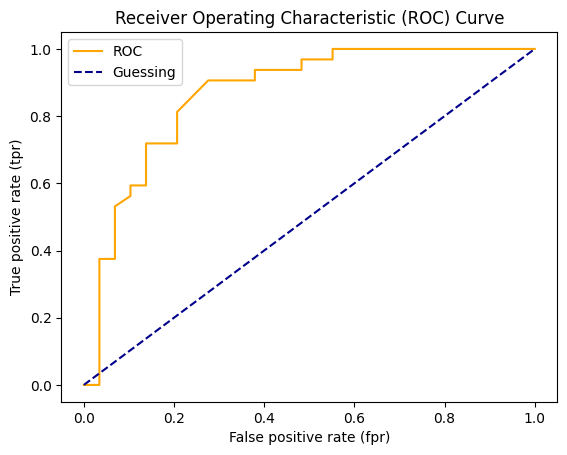

In [147]:
#create a function for plotting ROC curves
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """
    Plots a ROC curve given the false positive rate (fpr)
    and true positive rate (tpr) of a model.
    """
    # plot roc curve
    plt.plot(fpr, tpr, color="orange", label="ROC")
    #plot line with  no predictive power (baseline)
    plt.plot([0, 1], [0, 1], color="darkblue", linestyle="--", label="Guessing")

    #customize the plot
    plt.xlabel("False positive rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr, tpr)

In [148]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_probs_positive)

0.8669181034482759

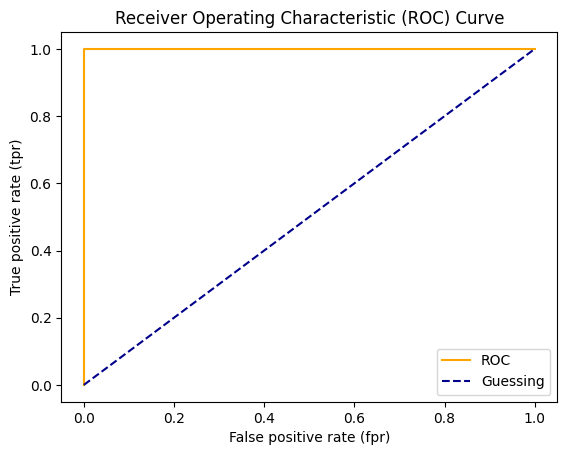

In [149]:
#plot perfect roc curved and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_test)
plot_roc_curve(fpr, tpr)

In [150]:
# perfect AUC score 
roc_auc_score(y_test, y_test)

1.0

**Confusion Metrix**

The next way to evalute a classification model is by using a confusion matrix. A confusion matrix is a quick way to compare  the labels a model and the actual labels it was supposed to predict.
in essence, this gives you an idea of where the model is getting confused.

In [151]:
from sklearn.metrics  import confusion_matrix

y_preds = clf.predict(x_test)
confusion_matrix(y_test, y_preds)

array([[23,  6],
       [ 6, 26]])

In [152]:
#Visualize confusion matrix with pd.crosstab()
pd.crosstab(y_test,
            y_preds,
            rownames=["Actual Label"],
            colnames=["Predicted Labels"])

Predicted Labels,0,1
Actual Label,,
0,23,6
1,6,26


In [153]:
23+26+6+6


61

In [154]:
len(x_test)

61

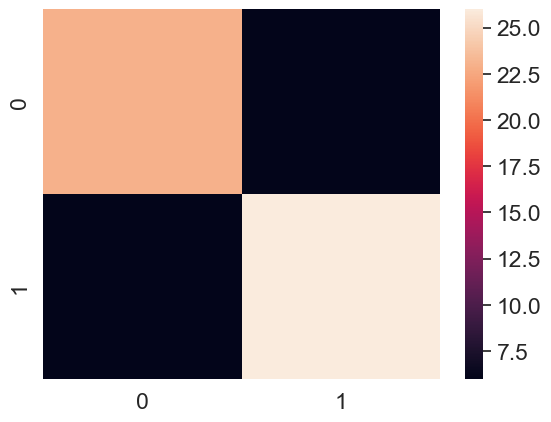

In [155]:
# MAke our confusion matrix more viual with seaborn's heatmap()
import seaborn as sns

#set the font scale 
sns.set(font_scale=1.5)

#create a confusion matrix
conf_mat = confusion_matrix(y_test, y_preds)

#Plot it using seaborn
sns.heatmap(conf_mat);

### creating a confusion matrix using Scikit-Learn
To use the new methods of creating a confusion matrix with Scikit-Learn you will need sklearn version1.0+


In [156]:
import sklearn 
sklearn.__version__

'1.8.0'

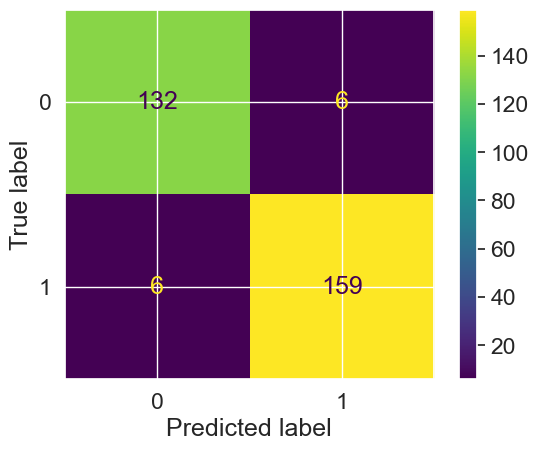

In [157]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    clf,
    x,
    y
)

plt.show()

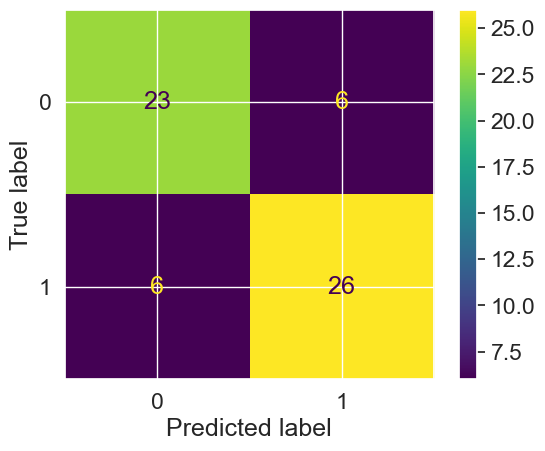

In [158]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_preds
)

plt.show()

In [159]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        29
           1       0.81      0.81      0.81        32

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [160]:
#Where precision and recall become valuable 
disease_true = np.zeros(10000)
disease_true[0] = 1#only one positive case

disease_preds = np.zeros(10000)#model predicts every case as 0

pd.DataFrame(classification_report(disease_true,
                                   disease_preds,
                                   output_dict=True))


C:\Users\DELL\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


To summerize classification metrics:
* | Metric      | Simple Meaning                     |
* | ----------- | ---------------------------------- |
* | Accuracy    | Overall kitna sahi                 |
* | Precision   | Positive bola to kitni baar sahi   |
* | Recall      | Actual positive me se kitne pakde  |
* | F1 Score    | Precision + Recall balance         |
* | Specificity | Actual negatives me se kitne pakde |
* | Sensitivity | Actual positives me se kitne pakde |
* |  ROC Curve   | Performance graph                  |
* |  AUC Score   | ROC ka overall score               |


### 4.2.2 Regression model evalution metrics

Model of evalution metrics documentation -https://scikit-learn.org/stable/modules/model_evaluation.html

#regression-metrics.
The ones we're going to cover are:
1. R^2 (pronounced r-squared) or coefficient of determination
2. Mean absolute error (MAE)
3. Mean squared error (MSE)

### R^2

"Target variable mein jo variation hai, uska kitna percent model explain kar pa raha hai."

Range of R²
* R² Value	Meaning
*  1.0    	Perfect prediction
* 0.9   	Very good
* 0.8   	Good
* 0.5	    Moderate
* 0.0	    Model kuch explain nahi kar raha
* Negative	Model average prediction se bhi worse hai

In [161]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)
x=housing_df.drop("target", axis=1)
y=housing_df["target"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)
model = RandomForestRegressor(n_estimators=100)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [162]:
model.score(x_test, y_test)

0.806652667101436

In [163]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [164]:
y_test.mean()

np.float64(2.0550030959302323)

In [165]:
from sklearn.metrics import r2_score

#fill an array with y_test mean
y_test_mean = np.full(len(y_test), y_test.mean())


In [166]:
y_test_mean[:10]

array([2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031,
       2.0550031, 2.0550031, 2.0550031, 2.0550031])

In [167]:
r2_score(y_true=y_test,
        y_pred=y_test_mean)

0.0

In [168]:
r2_score(y_true=y_test,
        y_pred=y_test)

1.0

**Mean absolute error (MAE)**
MAE is the average of the absolute difference between predictions and actual values.

    It gives you an idea  of how wrong your models predictions are.

In [169]:
#MAE
from sklearn.metrics import mean_absolute_error

y_preds = model.predict(x_test)
mae = mean_absolute_error(y_test, y_preds)
mae

0.32656738464147306

In [170]:
df = pd.DataFrame(data={"actual values":y_test,
                        "predicted values":y_preds})
df["diffrences"] = df["predicted values"] - df["actual values"]
df.head(10)

,actual values,predicted values,diffrences
20046,0.47700,0.493900,0.016900
3024,0.45800,0.754940,0.296940
15663,5.00001,4.928596,-0.071414
20484,2.18600,2.540240,0.354240
9814,2.78000,2.331760,-0.448240
13311,1.58700,1.660220,0.073220
7113,1.98200,2.343100,0.361100
7668,1.57500,1.663110,0.088110
18246,3.40000,2.474890,-0.925110
5723,4.46600,4.834478,0.368478


In [171]:
#MAE using formulas and differences
np.abs(df["diffrences"]).mean()

np.float64(0.32656738464147306)

### Mean squared era (MSE)
 MSE is the mean of the square of the errors between actual and predicted values.

In [172]:
#Mean squared error
from sklearn.metrics import mean_squared_error

y_preds = model.predict(x_test)
mse = mean_squared_error(y_test, y_preds)
mse

0.25336408094921037

In [173]:
df["squared_diffrences"] = np.square(df["diffrences"])
df.head()

,actual values,predicted values,diffrences,squared_diffrences
20046,0.47700,0.493900,0.016900,0.000286
3024,0.45800,0.754940,0.296940,0.088173
15663,5.00001,4.928596,-0.071414,0.005100
20484,2.18600,2.540240,0.354240,0.125486
9814,2.78000,2.331760,-0.448240,0.200919


In [174]:
# calcuate MSE by hand
squared = np.square(df["diffrences"])
squared.mean()

np.float64(0.25336408094921037)

In [175]:
df_large_error = df.copy()
df_large_error.iloc[0]["squared_diffrences"] = 16

C:\Users\DELL\AppData\Local\Temp\ipykernel_17104\1841711889.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df_large_error.iloc[0]["squared_diffrences"] = 16


In [176]:
df_large_error.head()

,actual values,predicted values,diffrences,squared_diffrences
20046,0.47700,0.493900,0.016900,0.000286
3024,0.45800,0.754940,0.296940,0.088173
15663,5.00001,4.928596,-0.071414,0.005100
20484,2.18600,2.540240,0.354240,0.125486
9814,2.78000,2.331760,-0.448240,0.200919


In [177]:
#claculate MSE with large error
df_large_error["squared_diffrences"].mean()

np.float64(0.25336408094921037)

In [178]:
df_large_error.iloc[1:100] = 20
df_large_error


,actual values,predicted values,diffrences,squared_diffrences
20046,0.47700,0.493900,0.016900,0.000286
3024,20.00000,20.000000,20.000000,20.000000
15663,20.00000,20.000000,20.000000,20.000000
20484,20.00000,20.000000,20.000000,20.000000
9814,20.00000,20.000000,20.000000,20.000000
...,...,...,...,...
15362,2.63300,2.219830,-0.413170,0.170709
16623,2.66800,1.947760,-0.720240,0.518746
18086,5.00001,4.836378,-0.163632,0.026775
2144,0.72300,0.717820,-0.005180,0.000027


In [179]:
#claculate MSE with large error
df_large_error["squared_diffrences"].mean()

np.float64(0.7294343981548149)

### 4.2.3 Finally using the 'scoring' parameters

In [180]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
x = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

clf = RandomForestClassifier(n_estimators=100)

In [181]:
np.random.seed(42)

#cross-validation accuracy
cv_acc = cross_val_score(clf,x,y, cv=5, scoring=None) #if scoring=None, estimator's default metric is used (accuracy for classification models)
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [182]:
# cross-validation accuracy
print(f"The cross-validated accuracy is:{np.mean(cv_acc)*100:.2f}%")

The cross-validated accuracy is:82.48%


In [183]:
np.random.seed(42)

cv_acc = cross_val_score(clf, x, y, cv=5, scoring="accuracy")
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [184]:
#precision 
np.random.seed(42)
cv_precision = cross_val_score(clf, x, y, cv=5, scoring="precision")
cv_precision

array([0.82352941, 0.93548387, 0.84848485, 0.79411765, 0.76315789])

In [185]:
# cross-validated precision 
print(f"the cross-validated precision is: {np.mean(cv_precision)}")

the cross-validated precision is: 0.8329547346025924


In [186]:
# recall
np.random.seed(42)
cv_recall = cross_val_score(clf, x, y, cv=5, scoring="recall")
cv_recall

array([0.84848485, 0.87878788, 0.84848485, 0.81818182, 0.87878788])

In [187]:
# cross-validated recall
print(f"the cross-validated precision is: {np.mean(cv_recall)}")

the cross-validated precision is: 0.8545454545454545


Let's see the scoring parameter being using for a regression problem....

In [188]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

x = housing_df.drop("target", axis=1)
y = housing_df["target"]

model = RandomForestRegressor(n_estimators=100)

In [189]:
np.random.seed(42)
cv_r2 = cross_val_score(model, x, y, cv=3, scoring=None)
np.mean(cv_r2)

np.float64(0.6545660727379677)

In [190]:
cv_r2

array([0.62156808, 0.72076221, 0.62136792])

In [191]:
# Mean squared error
cv_mse = cross_val_score(model, x, y, cv=5, scoring="neg_mean_squared_error")
np.mean(cv_mse)

np.float64(-0.43025886210571906)

In [192]:
# Mean absolute error 
cv_mae = cross_val_score(model, x, y, cv=5, scoring="neg_mean_absolute_error") 
np.mean(cv_mae)

np.float64(-0.4668242103585272)

## 4.3 Using different evalution metrics as scikit-learn functions

The 3rd way to evalute scikit-learn machine learning models/estimators is to using the 'sklearn.metrics'-module- https://scikit-learn.org/stable/api/sklearn.metrics.html#module-sklearn.metrics

In [193]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split

np.random.seed(42)
#Create x & y
x = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
#create model
clf = RandomForestClassifier()
#Fit the model
clf.fit(x_train, y_train)
#Make prediction 
y_preds = clf.predict(x_test)
#Evalute model using evalution function
print("Classifier metrics on the test set")
#print(f"Accuracy: {accuracy_score(y_test, clf.predict(x_test))*100:.2f}%")
print(f"Accuracy: {accuracy_score(y_test, y_preds)*100:.2f}%")
print(f"precision: {precision_score(y_test, y_preds)}")
print(f"Recall: {recall_score(y_test, y_preds)}")
print(f"F1: {f1_score(y_test, y_preds)}")


Classifier metrics on the test set
Accuracy: 85.25%
precision: 0.8484848484848485
Recall: 0.875
F1: 0.8615384615384616


In [194]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
np.random.seed(42)
#Create x & y
x = housing_df.drop("target", axis=1)
y = housing_df["target"]

# split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
#create model
model = RandomForestRegressor()
#Fit the model
model.fit(x_train, y_train)
#Make predictions
y_preds = model.predict(x_test)

#Evalute model using evalution function
print("Regression metrics on the test set")
print(f"R2 score: {r2_score(y_test, y_preds)}")
print(f"MAE: {mean_absolute_error(y_test, y_preds)}")
print(f"MSE: {mean_squared_error(y_test, y_preds)}")

Regression metrics on the test set
R2 score: 0.806652667101436
MAE: 0.32656738464147306
MSE: 0.25336408094921037


## 5. Improving a model

First predictions = baseline predictions.
First model = baseline model.

From a data perspective:
* Could we collect more data? (generally, the more data, the better)
* Could we improve our data?


From a model perspective:
* Is better model we could use?
* Could we improve the current model?

 Hyperparameters VS Parameters
 
* Parameters = model find these patterns in data 
* Hyperparameters = settings on a model you can adjust to(potentially) improve its ability to find patterns

Three ways to adjust hyperparameters:
1. By hand
2. Randomly with RandomSearchCV
3. Exhaustively with GridSearchCV

In [195]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100)

In [196]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

We are going to try and adjust:
* `max_depth`
* `max_features`
* `min_samples_leaf`
* `min_samples_split`
*  `n_estimators`




In [197]:
def evalute_preds(y_true, y_preds):
    """
    Performs evalution comparison on y_true labels vs. y_pred labels
    on a classification .
    """
    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds)
    recall  = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    metric_dict = {"accuracy": round(accuracy, 2),
                  "precision": round(precision, 2),
                  "recall": round(recall, 2),
                  "f1": round(f1, 2)}

    print(f"Acc: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1_score: {f1:.2f}")

    return metric_dict

In [198]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

#Shuffle the data
heart_disease_shuffled = heart_disease.sample(frac=1)

#Split into x & y 
x = heart_disease_shuffled.drop("target", axis=1)
y = heart_disease_shuffled["target"]

#Split the data into train, validation & test sets
train_split = round(0.7 * len(heart_disease_shuffled)) #70% of data
valid_split = round(train_split + 0.15 * len(heart_disease_shuffled)) #15% of data
x_train, y_train = x[:train_split], y[:train_split]
x_valid, y_valid = x[train_split:valid_split], y[train_split:valid_split]
x_test, y_test = x[valid_split:], y[valid_split]

# x_train, y_train → Model ko sikhane ke liye.
# x_valid, y_valid → Model ki performance check karne ke liye.
# x_test, y_test → Final result nikalne ke liye.

# Training Set = Jo questions aap practice karte ho.
# Validation Set = Mock test.
# Test Set = Actual board exam.

# y_valid → Validation dataset ke actual (sahi) labels hain.
# y_preds → Model ne validation dataset ke liye jo predictions kiye hain.
# evalute_preds() → Ek custom function hai jo actual values aur predicted values ko compare karke model ki performance nikalta hai.

clf = RandomForestClassifier()

clf.fit(x_train, y_train)

#Make  baseline predictions
y_preds = clf.predict(x_valid)

# Evalute the classifier on validation set
baseline_metrics = evalute_preds(y_valid, y_preds)
baseline_metrics

Acc: 82.22%
Precision: 0.81
Recall: 0.88
F1_score: 0.85


{'accuracy': 0.82, 'precision': 0.81, 'recall': 0.88, 'f1': 0.85}

In [199]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [200]:
np.random.seed(42)

#create a second classifier with different hyperparameters
clf_2 = RandomForestClassifier(n_estimators=100)
clf_2.fit(x_train, y_train)

#Make prediction with different hyperparameters
y_preds_2 = clf_2.predict(x_valid)

#Evaute the 2nd classifier
clf_2_metrics = evalute_preds(y_valid, y_preds_2)

Acc: 82.22%
Precision: 0.84
Recall: 0.84
F1_score: 0.84


### Hyperparameter tuning with RandomizedSearchCV

In [201]:
from sklearn.model_selection import RandomizedSearchCV

grid = {"n_estimators": [10,100,200,500,1000,1200],
        "max_depth": [None, 5, 10, 20, 30],
        "max_features": ["sqrt", "log2"],
        "min_samples_split": [2, 4, 6],
        "min_samples_leaf": [1, 2, 4]}

np.random.seed(42)

#Split into x & y
x = heart_disease_shuffled.drop("target", axis=1)
y = heart_disease_shuffled["target"]

#Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

#instantiate RandomForestClassifier
clf = RandomForestClassifier(n_jobs=1)

#Setup RandomizedSearchCV
rs_clf = RandomizedSearchCV(estimator=clf,
                            param_distributions=grid,
                            n_iter=10, #nimber of models to try
                            cv=5,
                            verbose=2)


#Fit the RandomizedSearchCV version of clf
rs_clf.fit(x_train, y_train);

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.5s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.4s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.4s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.4s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   1.4s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=4, n_estimators=100

In [202]:
rs_clf.best_params_

{'n_estimators': 200,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'max_depth': None}

In [204]:
# Make prediction with the best hyperparameters
rs_y_preds = rs_clf.predict(x_test)

#Evaluate the predictions
rs_metrics = evalute_preds(y_test, rs_y_preds)

Acc: 81.97%
Precision: 0.77
Recall: 0.86
F1_score: 0.81


### 5.3 Hyperparameters tuning with GridSearchCV

In [205]:
grid

{'n_estimators': [10, 100, 200, 500, 1000, 1200],
 'max_depth': [None, 5, 10, 20, 30],
 'max_features': ['sqrt', 'log2'],
 'min_samples_split': [2, 4, 6],
 'min_samples_leaf': [1, 2, 4]}